# 06 — Modélisation Machine Learning : Random Forest & XGBoost

## Projet : Smart City Energy Forecasting — Tetouan

Ce notebook correspond à l'étape **Machine Learning tabulaire** du pipeline KDD.

Objectif :

- utiliser le dataset déjà enrichi par feature engineering ;
- prédire la consommation électrique de la zone cible `target` ou `zone1_power` ;
- entraîner deux modèles ML :
  1. Random Forest Regressor ;
  2. XGBoost Regressor ;
- comparer les performances ;
- analyser les erreurs par heure, par jour et pendant les fortes charges ;
- sauvegarder les modèles, métriques, prédictions et figures.

Règles méthodologiques :

- aucun shuffle ;
- split strictement chronologique ;
- suppression des colonnes provoquant une fuite de données ;
- évaluation globale et métier ;
- préparation pour SHAP dans l'étape suivante.

## 1. Importation des bibliothèques et configuration

Le notebook importe les fonctions depuis `src/models_ml.py` pour garder les cellules propres et réutilisables.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Détection automatique de la racine du projet.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models_ml import (
    RandomForestConfig,
    XGBoostConfig,
    TemporalSplitConfig,
    set_global_seed,
    ensure_datetime_index,
    resolve_target_column,
    prepare_supervised_data,
    temporal_train_val_test_split,
    print_split_summary,
    train_evaluate_random_forest,
    train_evaluate_xgboost,
    metrics_to_frame,
    feature_importance_table,
    permutation_importance_table,
    evaluate_by_hour,
    evaluate_by_dayofweek,
    evaluate_peak_load,
    save_model,
    save_dataframe,
    save_feature_names,
    plot_actual_vs_predicted,
    plot_feature_importance,
    plot_error_by_hour,
)

set_global_seed(42)

PROJECT_ROOT

WindowsPath('C:/Users/Badr/UB/0_Inbox/00-projects-code/dm-pfm-project/smart-city-energy-forecasting-tetouan')

## 2. Définition des chemins

Le notebook cherche automatiquement le fichier de features généré à l'étape précédente.

Le nom recommandé est :

```text
data/processed/tetouan_features.csv

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
METRICS_DIR = RESULTS_DIR / "metrics"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [FIGURES_DIR, TABLES_DIR, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

candidate_feature_paths = [
    PROCESSED_DIR / "tetouan_features.csv",
    PROCESSED_DIR / "tetouan_features_hourly.csv",
    PROCESSED_DIR / "tetouan_hourly_features.csv",
    PROCESSED_DIR / "tetouan_features_lagged.csv",
    PROCESSED_DIR / "tetouan_ml_features.csv",
]

FEATURES_PATH = next((path for path in candidate_feature_paths if path.exists()), None)

if FEATURES_PATH is None:
    raise FileNotFoundError(
        "Aucun fichier de features trouvé. Vérifie que le notebook 04_feature_engineering "
        "a bien généré un fichier dans data/processed/. "
        f"Chemins testés : {[str(p) for p in candidate_feature_paths]}"
    )

print("Fichier de features utilisé :", FEATURES_PATH)

Fichier de features utilisé : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv


## 3. Chargement du dataset de features

Le dataset doit contenir les variables créées dans l'étape Feature Engineering :

- variables météo ;
- variables calendaires ;
- variables cycliques ;
- lags ;
- rolling features ;
- HDD/CDD ;
- cible `target` ou `zone1_power`.

In [3]:
df_features = pd.read_csv(FEATURES_PATH)
df_features = ensure_datetime_index(df_features)

print("Dimensions du dataset de features :", df_features.shape)
print("Période :", df_features.index.min(), "→", df_features.index.max())

df_features.head()

Dimensions du dataset de features : (8568, 111)
Période : 2017-01-08 00:00:00 → 2017-12-30 23:00:00


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,is_business_hour,is_morning_peak,is_evening_peak,is_peak_hour,is_off_peak,is_night,season,season_code,season_autumn,season_spring,season_summer,season_winter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_day_before_holiday,is_day_after_holiday,days_to_nearest_holiday,target_lag_1h,target_lag_2h,target_lag_3h,target_lag_6h,target_lag_12h,target_lag_24h,target_lag_48h,target_lag_72h,target_lag_168h,target_rolling_3h_mean,target_rolling_3h_std,target_rolling_3h_min,target_rolling_3h_max,target_rolling_6h_mean,target_rolling_6h_std,target_rolling_6h_min,target_rolling_6h_max,target_rolling_12h_mean,target_rolling_12h_std,target_rolling_12h_min,target_rolling_12h_max,target_rolling_24h_mean,target_rolling_24h_std,target_rolling_24h_min,target_rolling_24h_max,target_rolling_48h_mean,target_rolling_48h_std,target_rolling_48h_min,target_rolling_48h_max,target_rolling_168h_mean,target_rolling_168h_std,target_rolling_168h_min,target_rolling_168h_max,HDD,CDD,temperature_humidity_interaction,temperature_peak_interaction,CDD_peak_interaction,HDD_peak_interaction,general_diffuse_month_interaction,diffuse_month_interaction,temperature_lag_1h,humidity_lag_1h,HDD_lag_1h,CDD_lag_1h,temperature_lag_2h,humidity_lag_2h,HDD_lag_2h,CDD_lag_2h,temperature_lag_3h,humidity_lag_3h,HDD_lag_3h,CDD_lag_3h,temperature_lag_6h,humidity_lag_6h,HDD_lag_6h,CDD_lag_6h,temperature_lag_12h,humidity_lag_12h,HDD_lag_12h,CDD_lag_12h,is_high_temperature,is_heatwave_simulated,eval_is_high_load
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.273333,77.916667,0.0880,0.044667,0.123667,26633.924052,17421.276597,17871.807228,26633.924052,61927.007877,0.605689,0.402583,0,0,0,0,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,31526.075950,36025.316455,39227.341773,41583.797468,34033.417720,27193.924052,27172.658228,25979.746835,29197.974683,35592.911393,3158.861021,31526.075950,39227.341773,38309.704641,3528.606271,31526.075950,41583.797468,35676.624472,3851.666111,30612.658228,41583.797468,30612.700422,6430.701095,21502.784810,41583.797468,30662.468354,6600.138307,21453.164557,42924.556962,30102.121760,6962.283109,18540.759495,43572.658227,3.726667,0.0,1112.130556,0.0,0.0,0.0,0.044667,0.123667,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,13.070000,77.166667,4.930000,0.0,13.701667,72.591667,4.298333,0.0,14.575000,67.718333,3.425000,0.0,0,0,0
2017-01-08 01:00:00,14.441667,76.616667,0.0910,0.046500,0.137000,23640.506328,15492.401215,16057.831327,23640.506328,55190.738870,1.055631,0.858605,0,0,0,1,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,26633.924052,31526.075950,36025.316455,40846.582277,33486.582277,23961.518987,23968.607595,22892.151898,24657.215190,31395.105486,3835.138221,26633.924052,36025.316455,35818.059072,5213.136547,26633.924052,40846.582277,35060.000000,4587.406453,26633.924052,41583.797468,30589.367088,6444.065618,21502.784810,41583.797468,30651.244726,6606.518215,21453.164557,42924.556962,30086.859554,6967.057111,18540.759495,43572.658227,3.558333,0.0,1106.472361,0.0,0.0,0.0,0.046500,0.137000,14.273333,77.916667,3.726667,0.0,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,11.993333,79.133333,6.006667,0.0,14.928333,61.946667,3.071667,0.0,0,0,0
2017-01-08 02:00:00,14.216667,74.183333,0.0885,0.045833,0.123667,21817.721520,14072.340427,15021.686747,21817.721520,50911.748693,1.327609,1.149841,0,0,0,2,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.500000,0.866025,-0.781831,0.623

## 4. Vérification de la cible

La cible prioritaire est `target`.  
Si `target` n'existe pas, le notebook utilisera `zone1_power`.

In [4]:
TARGET_COL = resolve_target_column(df_features, preferred="target")

print("Colonne cible utilisée :", TARGET_COL)

if TARGET_COL not in df_features.columns:
    raise ValueError(f"La cible {TARGET_COL} est absente.")

print(df_features[TARGET_COL].describe())

Colonne cible utilisée : target
count     8568.000000
mean     32388.947991
std       7063.879193
min      14329.113923
25%      26349.622602
50%      32406.036106
75%      37351.686620
max      51844.261932
Name: target, dtype: float64


## 5. Préparation du problème supervisé

On transforme la série temporelle en problème tabulaire supervisé.

Point important : les colonnes de consommation instantanée comme `zone1_power`, `zone2_power`, `zone3_power` et `total_load` sont exclues des features pour éviter la fuite de données.

Les lags et rolling features restent autorisés, car ils représentent l'information passée.

In [5]:
X, y, FEATURE_COLS = prepare_supervised_data(
    df=df_features,
    target_col=TARGET_COL,
    feature_cols=None,
    forbidden_features=None,
    drop_current_zone_loads=True,
)

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
print("Nombre de features utilisées :", len(FEATURE_COLS))

print("\nPremières features :")
print(FEATURE_COLS[:30])

Dimensions X : (8568, 105)
Dimensions y : (8568,)
Nombre de features utilisées : 105

Premières features :
['temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'target_rolling_zscore', 'total_load_rolling_zscore', 'is_target_outlier', 'is_total_load_outlier', 'is_load_outlier', 'hour', 'dayofweek', 'dayofmonth', 'dayofyear', 'weekofyear', 'month', 'quarter', 'is_weekend', 'is_business_hour', 'is_morning_peak', 'is_evening_peak', 'is_peak_hour', 'is_off_peak', 'is_night', 'season_code', 'season_autumn', 'season_spring', 'season_summer', 'season_winter', 'hour_sin']


In [6]:
# Vérifications de sécurité anti-data leakage.
leakage_candidates = {"target", "zone1_power", "zone2_power", "zone3_power", "total_load"}

detected_leakage = sorted([col for col in FEATURE_COLS if col in leakage_candidates])

if detected_leakage:
    raise ValueError(f"Colonnes de fuite détectées dans les features : {detected_leakage}")

print("Contrôle anti-leakage OK.")

Contrôle anti-leakage OK.


## 6. Split temporel train / validation / test

La validation est chronologique :

- train : 70 % ;
- validation : 15 % ;
- test : 15 %.

Aucun mélange aléatoire n'est autorisé en forecasting.

In [7]:
split_config = TemporalSplitConfig(
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

X_train, X_val, X_test, y_train, y_val, y_test = temporal_train_val_test_split(
    X,
    y,
    config=split_config,
)

print_split_summary(X_train, X_val, X_test)

print("\nShapes :")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

Résumé des splits temporels
------------------------------------------------------------
Train : 2017-01-08 00:00:00 → 2017-09-14 20:00:00 | 5997 lignes
Val   : 2017-09-14 21:00:00 → 2017-11-07 09:00:00 | 1285 lignes
Test  : 2017-11-07 10:00:00 → 2017-12-30 23:00:00 | 1286 lignes

Shapes :
X_train : (5997, 105)
X_val   : (1285, 105)
X_test  : (1286, 105)


## 7. Modèle 1 — Random Forest Regressor

Random Forest sert de baseline Machine Learning robuste.

Il est adapté ici parce qu'il :

- capture des relations non linéaires ;
- fonctionne bien avec des features tabulaires ;
- n'exige pas de normalisation ;
- fournit une première importance des variables.

In [8]:
rf_config = RandomForestConfig(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

rf_model, rf_metrics, rf_pred_df = train_evaluate_random_forest(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    config=rf_config,
    model_name="RandomForest",
)

rf_metrics

{'model': 'RandomForest',
 'MAE': 1064.4499756754526,
 'RMSE': 1277.8239187059282,
 'MAPE': 3.6174950602110045,
 'sMAPE': 3.547623000195594,
 'R2': 0.9547099939017064,
 'Bias': 843.5590506582945,
 'n_obs': 1286}

## 8. Modèle 2 — XGBoost Regressor

XGBoost est le modèle principal de cette étape.

Il est souvent performant pour les séries temporelles transformées en problème tabulaire, surtout lorsque les features contiennent :

- lags ;
- rolling statistics ;
- météo ;
- calendrier ;
- variables cycliques ;
- HDD/CDD.

Si XGBoost n'est pas installé :

```bash
pip install xgboost

In [9]:
xgb_config = XGBoostConfig(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3.0,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=1.00,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model, xgb_metrics, xgb_pred_df = train_evaluate_xgboost(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    config=xgb_config,
    early_stopping_rounds=50,
    model_name="XGBoost",
)

xgb_metrics

{'model': 'XGBoost',
 'MAE': 648.039878733962,
 'RMSE': 878.403535855662,
 'MAPE': 2.2363873164386625,
 'sMAPE': 2.2152977804366505,
 'R2': 0.9785982885939397,
 'Bias': 327.1425030830422,
 'n_obs': 1286}

## 9. Comparaison globale des modèles

Les métriques utilisées sont :

- MAE : erreur absolue moyenne ;
- RMSE : pénalise fortement les grandes erreurs ;
- MAPE : erreur relative moyenne en pourcentage ;
- sMAPE : version symétrique du MAPE ;
- R² : proportion de variance expliquée ;
- Bias : tendance moyenne à surestimer ou sous-estimer.

In [10]:
metrics_table = metrics_to_frame([rf_metrics, xgb_metrics])

metrics_table

,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,XGBoost,648.039879,878.403536,2.236387,2.215298,0.978598,327.142503,1286
1,RandomForest,1064.449976,1277.823919,3.617495,3.547623,0.954710,843.559051,1286


In [11]:
metrics_path = METRICS_DIR / "06_ml_xgboost_metrics.csv"

save_dataframe(metrics_table, metrics_path, index=False)

print("Métriques sauvegardées :", metrics_path)

Métriques sauvegardées : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\metrics\06_ml_xgboost_metrics.csv


## 10. Visualisation réel vs prédit

On compare la série réelle et la série prédite sur le jeu de test.

Cette visualisation est obligatoire dans le rapport, car elle montre si le modèle suit réellement la dynamique temporelle.

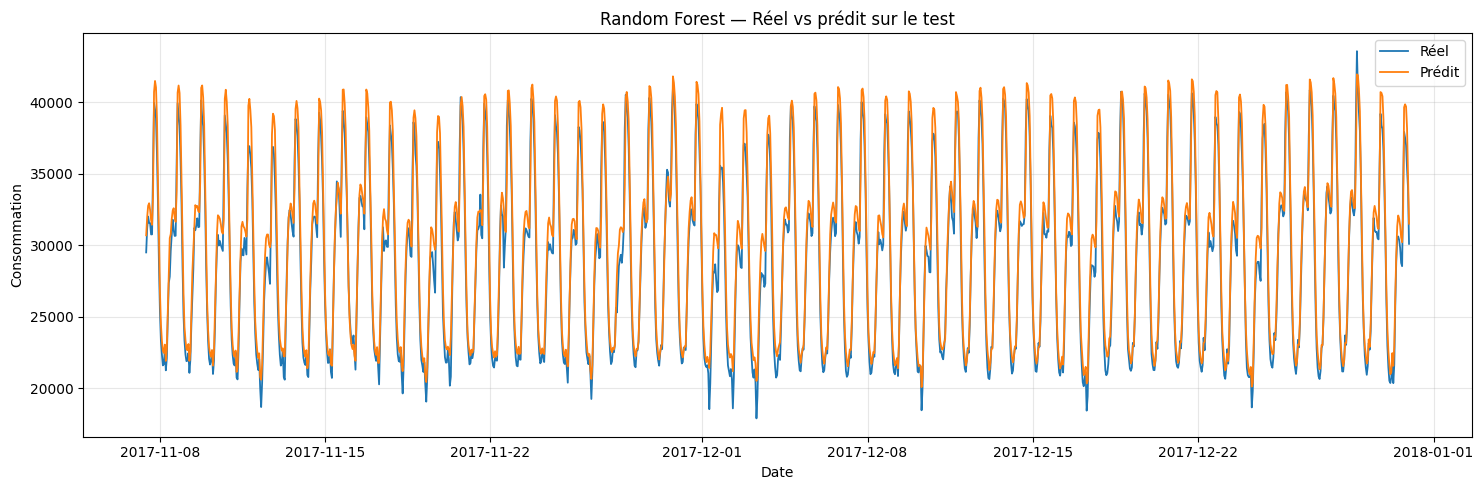

In [12]:
fig = plot_actual_vs_predicted(
    rf_pred_df,
    title="Random Forest — Réel vs prédit sur le test",
    path=FIGURES_DIR / "06_random_forest_actual_vs_predicted.png",
)
plt.show()

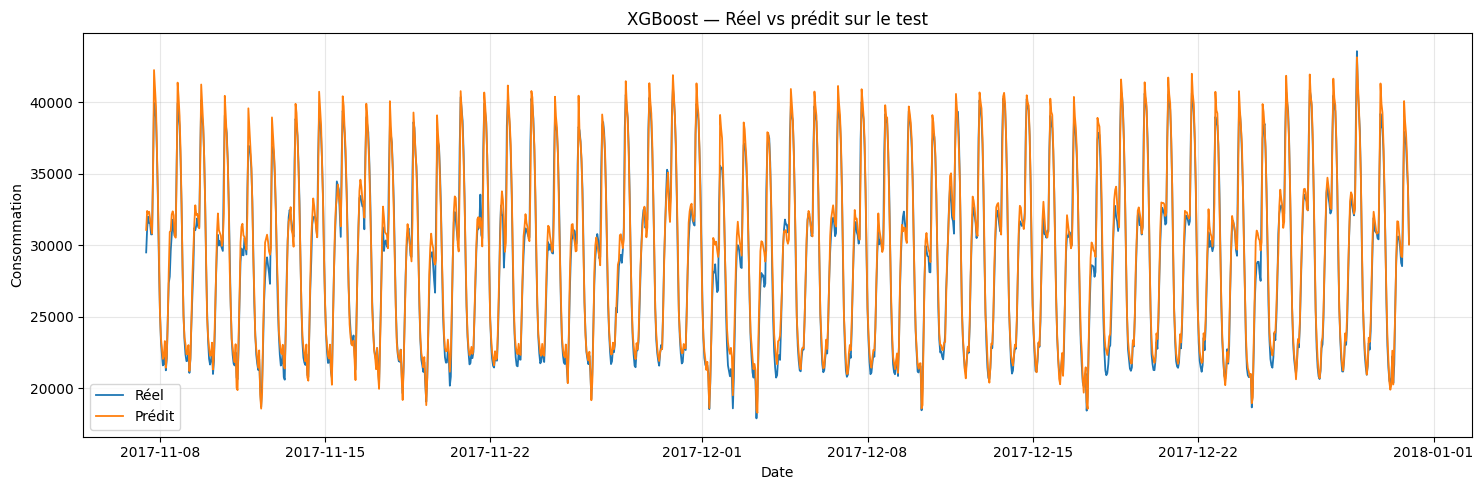

In [13]:
fig = plot_actual_vs_predicted(
    xgb_pred_df,
    title="XGBoost — Réel vs prédit sur le test",
    path=FIGURES_DIR / "06_xgboost_actual_vs_predicted.png",
)
plt.show()

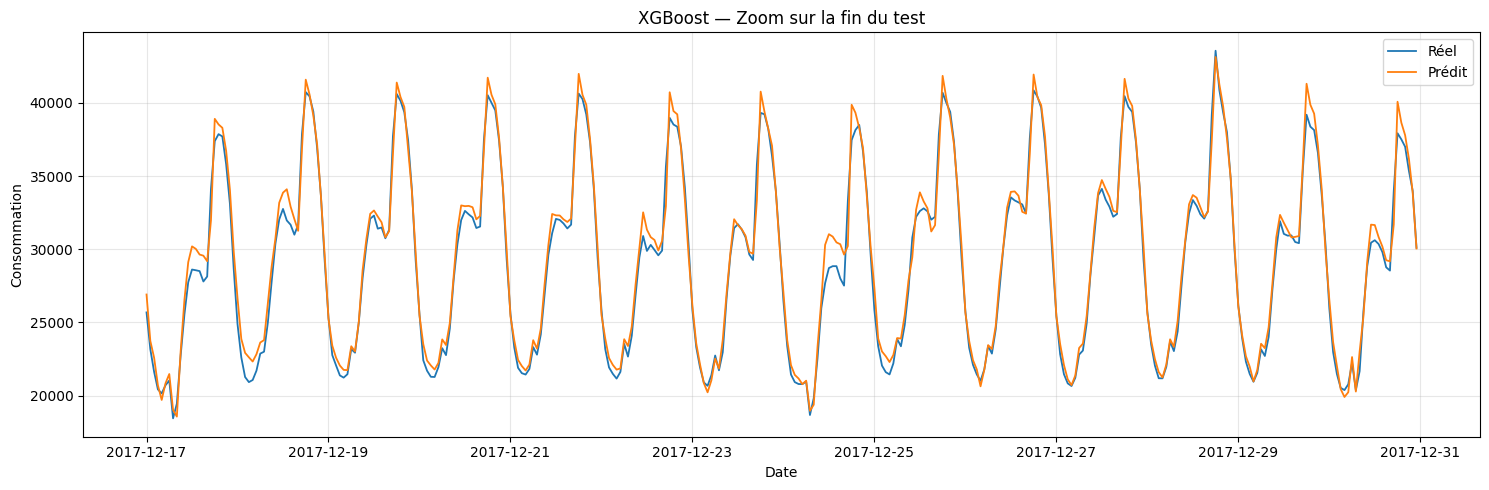

In [14]:
# Zoom sur les 14 derniers jours du test, si le test contient assez de points.
# Après resampling horaire : 24 * 14 = 336 points.
# Si le dataset reste à 10 minutes : ce zoom représentera moins de jours, mais reste utile visuellement.

zoom_points = min(len(xgb_pred_df), 24 * 14)

fig = plot_actual_vs_predicted(
    xgb_pred_df,
    title="XGBoost — Zoom sur la fin du test",
    path=FIGURES_DIR / "06_xgboost_zoom_test_end.png",
    max_points=zoom_points,
)
plt.show()

## 11. Importance native des variables

L'importance native indique les variables les plus utilisées par les modèles.

Cette analyse ne remplace pas SHAP, mais elle permet déjà de vérifier si les lags, les variables météo et les variables temporelles sont exploités.

In [15]:
rf_importance = feature_importance_table(
    rf_model,
    FEATURE_COLS,
    top_n=30,
)

xgb_importance = feature_importance_table(
    xgb_model,
    FEATURE_COLS,
    top_n=30,
)

save_dataframe(
    rf_importance,
    TABLES_DIR / "06_random_forest_feature_importance.csv",
    index=False,
)

save_dataframe(
    xgb_importance,
    TABLES_DIR / "06_xgboost_feature_importance.csv",
    index=False,
)

print("Top 15 features Random Forest")
display(rf_importance.head(15))

print("Top 15 features XGBoost")
display(xgb_importance.head(15))

Top 15 features Random Forest


,feature,importance,rank
0,target_lag_24h,0.135205,1
1,target_lag_168h,0.094937,2
2,target_lag_48h,0.090435,3
3,target_lag_72h,0.085672,4
4,target_lag_1h,0.085041,5
5,hour,0.063733,6
6,target_rolling_3h_min,0.041321,7
7,hour_sin,0.038205,8
8,target_rolling_3h_mean,0.035757,9
9,target_lag_2h,0.029158,10


Top 15 features XGBoost


,feature,importance,rank
0,target_lag_24h,0.459680,1
1,target_lag_168h,0.141074,2
2,target_lag_48h,0.086542,3
3,eval_is_high_load,0.075665,4
4,target_lag_1h,0.066537,5
5,is_business_hour,0.021057,6
6,is_peak_hour,0.020083,7
7,is_night,0.018570,8
8,hour,0.011758,9
9,is_day_before_holiday,0.007296,10


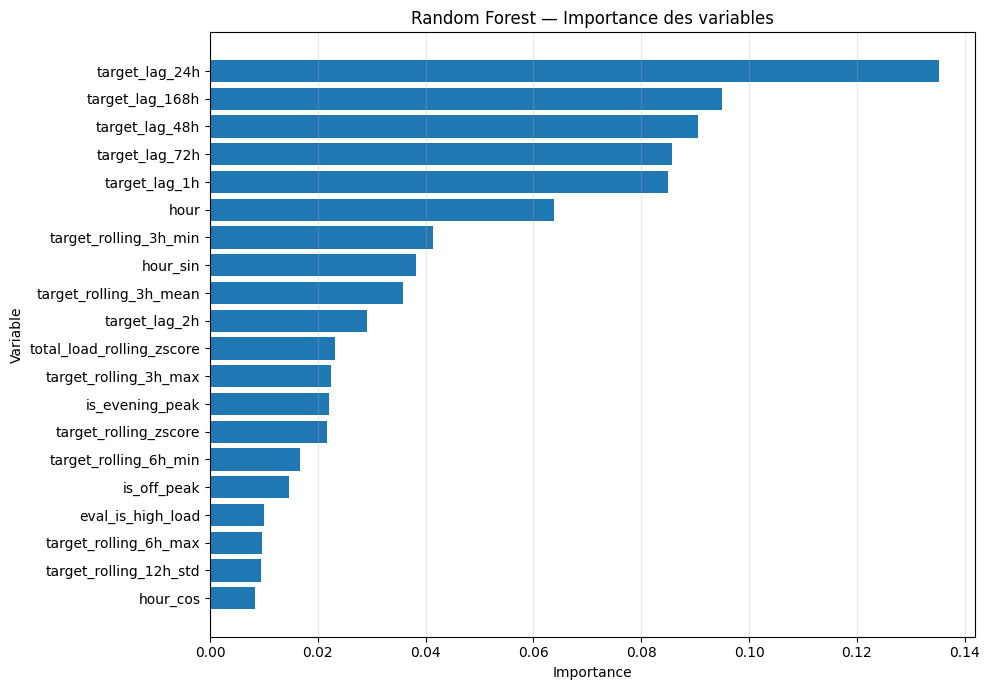

In [16]:
fig = plot_feature_importance(
    rf_importance,
    title="Random Forest — Importance des variables",
    path=FIGURES_DIR / "06_random_forest_feature_importance.png",
    top_n=20,
)
plt.show()

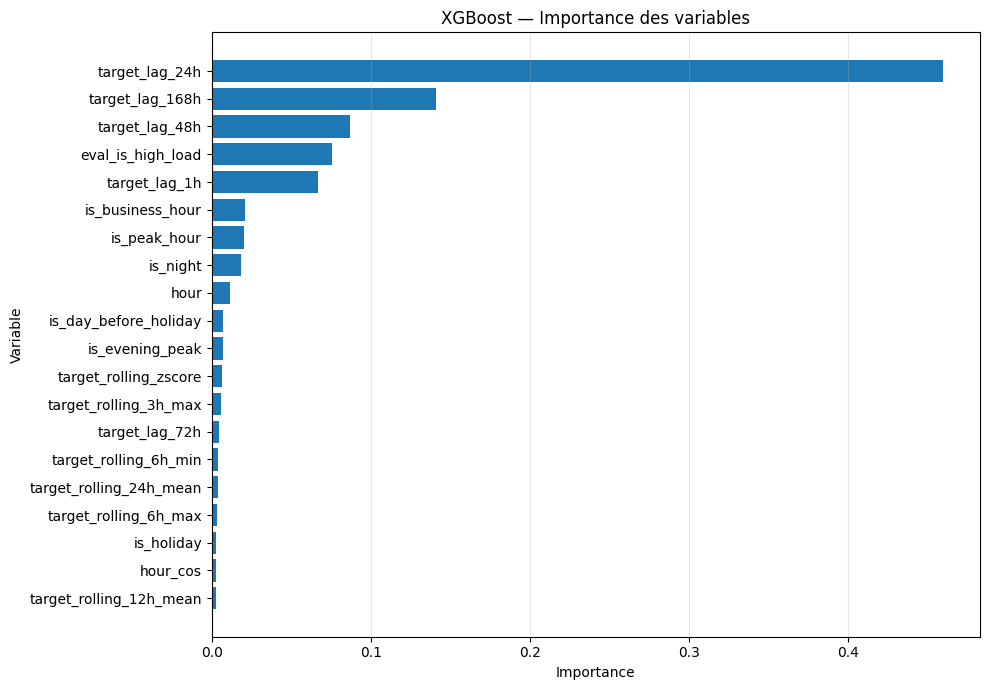

In [17]:
fig = plot_feature_importance(
    xgb_importance,
    title="XGBoost — Importance des variables",
    path=FIGURES_DIR / "06_xgboost_feature_importance.png",
    top_n=20,
)
plt.show()

## 12. Analyse des erreurs par heure

Un modèle de prévision énergétique ne doit pas seulement être bon en moyenne.

Il doit aussi rester fiable pendant les heures critiques : matin, soirée, heures de pointe ou périodes de forte activité.

In [18]:
rf_hourly_metrics = evaluate_by_hour(rf_pred_df)
xgb_hourly_metrics = evaluate_by_hour(xgb_pred_df)

save_dataframe(
    rf_hourly_metrics,
    METRICS_DIR / "06_random_forest_metrics_by_hour.csv",
    index=False,
)

save_dataframe(
    xgb_hourly_metrics,
    METRICS_DIR / "06_xgboost_metrics_by_hour.csv",
    index=False,
)

xgb_hourly_metrics

,hour,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,0,XGBoost,447.430560,652.461755,1.746378,1.718635,-1.382366,265.696611,53
1,1,XGBoost,432.197938,523.691268,1.861942,1.838750,-0.436636,372.440056,53
2,2,XGBoost,578.539367,657.819667,2.631761,2.588089,-1.055246,556.542357,53
3,3,XGBoost,550.932341,647.367216,2.574643,2.530573,-0.766814,518.515851,53
4,4,XGBoost,430.651959,517.104382,2.018125,1.996970,-0.001715,275.387526,53
5,5,XGBoost,388.700775,494.202135,1.759983,1.737470,0.316239,339.325307,53
6,6,XGBoost,360.022831,455.808911,1.649413,1.634215,0.781155,229.281858,53
7,7,XGBoost,374.425847,483.998203,1.756750,1.740445,0.907705,210.993476,53
8,8,XGBoost,526.859312,665.890710,2.308445,2.292055,0.864625,204.211926,53
9,9,XGBoost,518.428420,619.178079,1.977348,1.954926,0.865591,352.528132,53


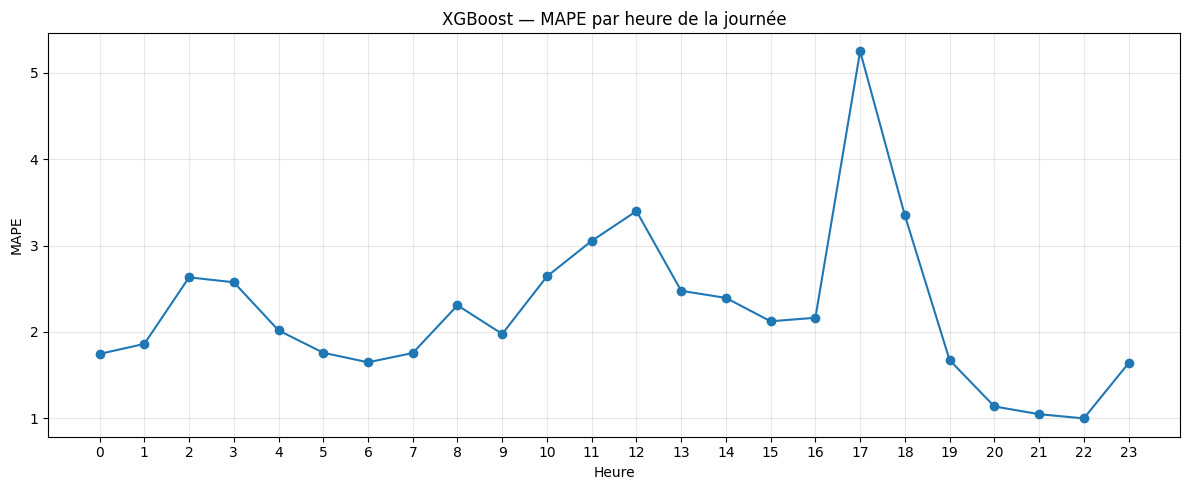

In [19]:
fig = plot_error_by_hour(
    xgb_hourly_metrics,
    title="XGBoost — MAPE par heure de la journée",
    metric_col="MAPE",
    path=FIGURES_DIR / "06_xgboost_mape_by_hour.png",
)
plt.show()

## 13. Analyse des erreurs par jour de semaine

Cette analyse vérifie si le modèle est moins performant pendant certains jours, notamment le week-end.

In [20]:
rf_dow_metrics = evaluate_by_dayofweek(rf_pred_df)
xgb_dow_metrics = evaluate_by_dayofweek(xgb_pred_df)

save_dataframe(
    rf_dow_metrics,
    METRICS_DIR / "06_random_forest_metrics_by_dayofweek.csv",
    index=False,
)

save_dataframe(
    xgb_dow_metrics,
    METRICS_DIR / "06_xgboost_metrics_by_dayofweek.csv",
    index=False,
)

xgb_dow_metrics

,dayofweek,day_name,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,0,Lundi,XGBoost,756.717418,921.123791,2.734521,2.697982,0.977158,368.610383,168
1,1,Mardi,XGBoost,496.132896,652.962124,1.631947,1.622558,0.988207,255.309687,182
2,2,Mercredi,XGBoost,563.453476,737.698070,1.888054,1.869927,0.985871,321.297557,192
3,3,Jeudi,XGBoost,508.098052,653.117670,1.728904,1.717362,0.988501,282.124322,192
4,4,Vendredi,XGBoost,714.389342,1018.530675,2.398582,2.376888,0.967426,359.500584,192
5,5,Samedi,XGBoost,656.960953,898.386695,2.296106,2.278151,0.975966,249.299975,192
6,6,Dimanche,XGBoost,874.508458,1174.118926,3.117524,3.082019,0.959418,473.605022,168


## 14. Test sur les fortes charges

On isole les observations où la consommation réelle dépasse le 90e percentile du test.

Cette analyse est importante pour un Smart Grid : un modèle peut être bon en moyenne, mais inutile s'il échoue pendant les pics.

In [21]:
rf_peak_metrics = evaluate_peak_load(
    rf_pred_df,
    quantile=0.90,
)

xgb_peak_metrics = evaluate_peak_load(
    xgb_pred_df,
    quantile=0.90,
)

peak_table = metrics_to_frame([rf_peak_metrics, xgb_peak_metrics])

save_dataframe(
    peak_table,
    METRICS_DIR / "06_ml_peak_load_metrics.csv",
    index=False,
)

peak_table

,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs,threshold,quantile
0,XGBoost_peak_q0.90,767.445058,936.568624,1.957234,1.938793,-0.218432,563.734138,129,37926.816808,0.9
1,RandomForest_peak_q0.90,1394.076896,1531.357934,3.569664,3.521769,-2.257434,1115.639690,129,37926.816808,0.9


## 15. Importance par permutation

L'importance native peut être biaisée par certaines propriétés des arbres.

L'importance par permutation mesure la perte de performance quand une variable est mélangée. Elle donne donc une lecture complémentaire de l'impact réel des features.

In [22]:
# Pour accélérer, on calcule la permutation sur un sous-échantillon du test si nécessaire.

MAX_PERMUTATION_ROWS = 2000

if len(X_test) > MAX_PERMUTATION_ROWS:
    X_perm = X_test.tail(MAX_PERMUTATION_ROWS)
    y_perm = y_test.loc[X_perm.index]
else:
    X_perm = X_test
    y_perm = y_test

xgb_perm_importance = permutation_importance_table(
    xgb_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    top_n=30,
)

save_dataframe(
    xgb_perm_importance,
    TABLES_DIR / "06_xgboost_permutation_importance.csv",
    index=False,
)

xgb_perm_importance.head(15)

,feature,importance_mean,importance_std,rank
0,target_lag_1h,1819.355267,15.833916,1
1,target_lag_24h,1154.935289,23.045262,2
2,target_rolling_zscore,646.949091,23.180026,3
3,target_lag_168h,315.709702,7.455025,4
4,target_lag_48h,195.360055,6.128847,5
5,diffuse_month_interaction,55.242160,3.262130,6
6,total_load_rolling_zscore,50.003855,4.788165,7
7,general_diffuse_flows,37.941335,1.666867,8
8,target_rolling_12h_max,36.938825,1.868208,9
9,general_diffuse_month_interaction,29.197816,2.785500,10


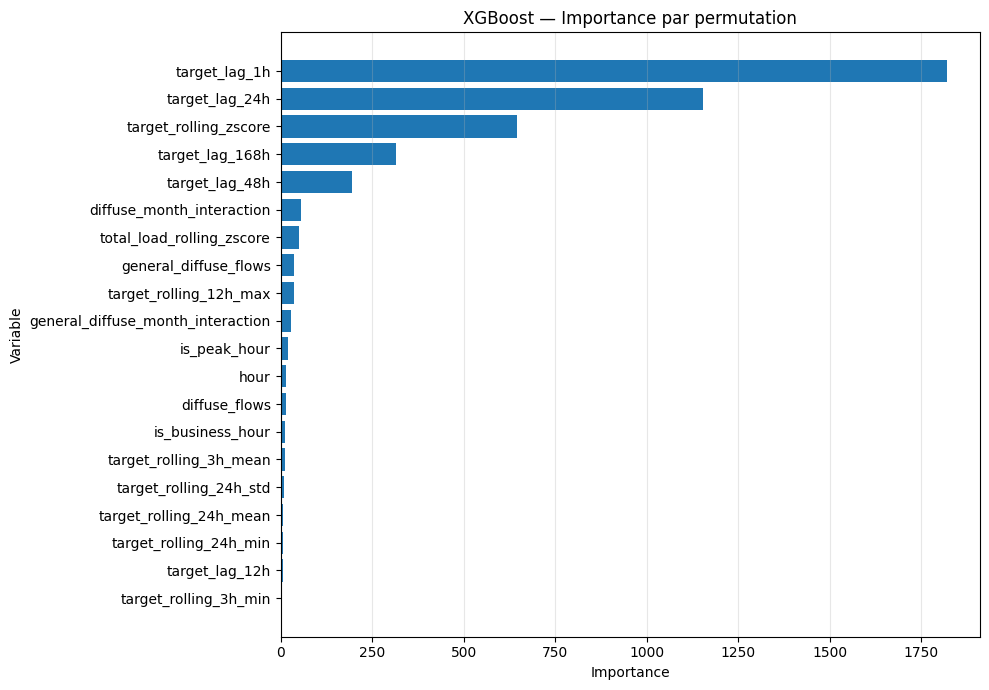

In [23]:
fig = plot_feature_importance(
    xgb_perm_importance,
    title="XGBoost — Importance par permutation",
    path=FIGURES_DIR / "06_xgboost_permutation_importance.png",
    top_n=20,
)
plt.show()

## 16. Sauvegarde des modèles, features et prédictions

Les sorties sauvegardées seront utilisées dans les étapes suivantes :

- notebook SHAP/LIME ;
- comparaison finale des modèles ;
- rapport final ;
- dashboard éventuel.

In [24]:
# Sauvegarde des prédictions.
save_dataframe(
    rf_pred_df,
    PREDICTIONS_DIR / "06_random_forest_predictions.csv",
    index=False,
)

save_dataframe(
    xgb_pred_df,
    PREDICTIONS_DIR / "06_xgboost_predictions.csv",
    index=False,
)

# Sauvegarde des modèles.
save_model(
    rf_model,
    MODELS_DIR / "random_forest_model.pkl",
)

save_model(
    xgb_model,
    MODELS_DIR / "xgboost_model.pkl",
)

# Sauvegarde de la liste des features.
save_feature_names(
    FEATURE_COLS,
    MODELS_DIR / "ml_feature_names.json",
)

print("Sauvegardes terminées :")
print("-", MODELS_DIR / "random_forest_model.pkl")
print("-", MODELS_DIR / "xgboost_model.pkl")
print("-", MODELS_DIR / "ml_feature_names.json")
print("-", PREDICTIONS_DIR / "06_random_forest_predictions.csv")
print("-", PREDICTIONS_DIR / "06_xgboost_predictions.csv")

Sauvegardes terminées :
- C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\models\random_forest_model.pkl
- C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\models\xgboost_model.pkl
- C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\models\ml_feature_names.json
- C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\predictions\06_random_forest_predictions.csv
- C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\predictions\06_xgboost_predictions.csv


## 17. Synthèse automatique pour le rapport

Cette cellule génère un texte court basé sur les vraies métriques obtenues après exécution.

Ne pas écrire de valeurs inventées dans le rapport : utiliser uniquement les résultats affichés ici.

In [25]:
best_row = metrics_table.iloc[0]

summary = f"""
Synthèse ML — Notebook 06
-------------------------

Le meilleur modèle ML sur le jeu de test est : {best_row['model']}.

Performances sur le test :
- MAE   = {best_row['MAE']:.3f}
- RMSE  = {best_row['RMSE']:.3f}
- MAPE  = {best_row['MAPE']:.3f} %
- sMAPE = {best_row['sMAPE']:.3f} %
- R²    = {best_row['R2']:.4f}
- Bias  = {best_row['Bias']:.3f}

Interprétation :
Le modèle ML transforme la série temporelle en problème supervisé tabulaire à partir
des variables de calendrier, météo, lags, rolling features et indicateurs thermiques.

L'analyse globale des métriques doit être complétée par :
- l'analyse par heure ;
- l'analyse par jour de semaine ;
- le test sur les fortes charges ;
- l'importance des variables ;
- l'explicabilité SHAP dans le notebook suivant.

Cette étape permet de comparer Random Forest et XGBoost et de sélectionner le modèle
ML le plus pertinent pour l'interprétation et la valorisation Smart City.
""".strip()

summary_path = RESULTS_DIR / "06_ml_xgboost_summary.txt"
summary_path.write_text(summary, encoding="utf-8")

print(summary)
print("\nSynthèse sauvegardée :", summary_path)

Synthèse ML — Notebook 06
-------------------------

Le meilleur modèle ML sur le jeu de test est : XGBoost.

Performances sur le test :
- MAE   = 648.040
- RMSE  = 878.404
- MAPE  = 2.236 %
- sMAPE = 2.215 %
- R²    = 0.9786
- Bias  = 327.143

Interprétation :
Le modèle ML transforme la série temporelle en problème supervisé tabulaire à partir
des variables de calendrier, météo, lags, rolling features et indicateurs thermiques.

L'analyse globale des métriques doit être complétée par :
- l'analyse par heure ;
- l'analyse par jour de semaine ;
- le test sur les fortes charges ;
- l'importance des variables ;
- l'explicabilité SHAP dans le notebook suivant.

Cette étape permet de comparer Random Forest et XGBoost et de sélectionner le modèle
ML le plus pertinent pour l'interprétation et la valorisation Smart City.

Synthèse sauvegardée : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\06_ml_xgboost_summary.txt


## 18. Conclusion du notebook

À la fin de cette étape, on doit obtenir :

- un modèle Random Forest sauvegardé ;
- un modèle XGBoost sauvegardé ;
- un tableau comparatif des métriques ;
- les prédictions sur le test ;
- les importances natives des variables ;
- les importances par permutation ;
- les erreurs par heure ;
- les erreurs par jour de semaine ;
- les métriques sur les fortes charges.

L'étape suivante logique est :

```text
08_xai_shap_lime.ipynb